<a href="https://colab.research.google.com/github/fcoliveira-utfpr/IDFTec/blob/main/analise_estatistica_idf_municipios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descriptive Statistical Analysis — Annual Maximum Daily Rainfall and IDF Curves by Municipality (Brazil)

This notebook consolidates the results generated by `extrair_chuva_maxima.py` (annual maximum daily rainfall series, 1961–2025, Xavier BR-DWGD grid) and `calcular_idf_municipios.py` (IDF curves calibrated per municipality), with national and per-state descriptive statistics, heatmaps, and choropleth maps (`geobr`).

**Data sources:**
- `xavier_chuva_maxima_diaria_anual_municipios_1961_2025.json` — 362,115 records (5,571 municipalities × 65 years)
- `idf_municipios.json` — IDF curves for 5,569 municipalities
- `idf_municipios_ignorados.json` — municipalities without a valid series


In [1]:
#Instalation
!pip install geobr    -q

# Install cartopy if not already installed
!pip install -q cartopy matplotlib-scalebar

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geobr

import warnings
warnings.filterwarnings('ignore')

import math
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

BASE = Path.cwd()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 65.8 MB/s eta 0:00:00


## 1. Data loading and preparation

The IBGE code already contains the state code in its first 2 digits (e.g. `51` = Mato Grosso) — used here to fix a record with an empty state in the centroids asset (see note just below).

In [2]:
CODIGO_UF = {
    '11': 'RO', '12': 'AC', '13': 'AM', '14': 'RR', '15': 'PA', '16': 'AP', '17': 'TO',
    '21': 'MA', '22': 'PI', '23': 'CE', '24': 'RN', '25': 'PB', '26': 'PE', '27': 'AL', '28': 'SE', '29': 'BA',
    '31': 'MG', '32': 'ES', '33': 'RJ', '35': 'SP',
    '41': 'PR', '42': 'SC', '43': 'RS',
    '50': 'MS', '51': 'MT', '52': 'GO', '53': 'DF',
}


def corrigir_uf(codigo_ibge, uf):
    return uf if uf else CODIGO_UF.get(codigo_ibge[:2], uf)

import requests # Import the requests library to handle URLs

# Correctly load JSON from URL using requests
url_df_long = 'https://raw.githubusercontent.com/fcoliveira-utfpr/IDFTec/refs/heads/main/xavier_chuva_maxima_diaria_anual_municipios_1961_2025.json'
df_long = pd.DataFrame(requests.get(url_df_long).json())
df_long['uf'] = df_long.apply(lambda r: corrigir_uf(r['codigo_ibge'], r['uf']), axis=1)

DURACOES = ['5 min', '10 min', '15 min', '20 min', '25 min', '30 min', '60 min',
            '360 min', '480 min', '600 min', '720 min', '1440 min']
PERIODOS_RETORNO = [5, 10, 25, 50, 100]

url_idf_registros = 'https://raw.githubusercontent.com/fcoliveira-utfpr/IDFTec/refs/heads/main/idf_municipios.json'
idf_registros = requests.get(url_idf_registros).json()

linhas_idf = []
for r in idf_registros:
    linha = {
        'codigo_ibge': r['codigo_ibge'], 'nome_municipio': r['nome_municipio'], 'uf': r['uf'],
        'n_anos': r['n_anos'], 'distribuicao': r['distribuicao'],
        'ks_d': r['ks_d'], 'ks_p_valor': r['ks_p_valor'],
        'idf_k': r['idf']['k'], 'idf_a': r['idf']['a'], 'idf_b': r['idf']['b'], 'idf_c': r['idf']['c'],
        'idf_r2': r['idf']['r2'], 'idf_mae': r['idf']['mae'], 'idf_rmse': r['idf']['rmse'],
    }
    for duracao in DURACOES:
        chave = duracao.replace(' ', '')
        for tr in PERIODOS_RETORNO:
            linha[f'i_{chave}_{tr}anos'] = r['quantis_mm_h'][duracao][str(tr)]
    linhas_idf.append(linha)

df_idf = pd.DataFrame(linhas_idf)
df_idf['uf'] = df_idf.apply(lambda r: corrigir_uf(r['codigo_ibge'], r['uf']), axis=1)

url_df_ignorados = 'https://raw.githubusercontent.com/fcoliveira-utfpr/IDFTec/refs/heads/main/idf_municipios_ignorados.json'
df_ignorados = pd.DataFrame(requests.get(url_df_ignorados).json())

print(f'Série bruta: {len(df_long):,} registros ({df_long["codigo_ibge"].nunique()} municípios x {df_long["ano"].nunique()} anos)')
print(f'Municípios com curva IDF: {len(df_idf)}')
print(f'Municípios ignorados (dados insuficientes): {len(df_ignorados)}')
df_ignorados

Série bruta: 362,115 registros (5571 municípios x 65 anos)
Municípios com curva IDF: 5569
Municípios ignorados (dados insuficientes): 2


,codigo_ibge,nome_municipio,motivo
0,3205309,Vitória,"dados insuficientes (0 ano(s) válido(s), mínim..."
1,2605459,Fernando de Noronha,"dados insuficientes (0 ano(s) válido(s), mínim..."


### Notes

- **Fernando de Noronha (PE)** and **Vitória (ES)**: no valid series (island outside the Xavier grid coverage; asset centroid falling in the ocean, respectively) — excluded from every statistic in this notebook.
- **Boa Esperança do Norte (MT, code 5101837)**: had an empty state in the centroids asset (fixed above) and **has no polygon in the 2020 `geobr` mesh** used for the municipal maps — so it doesn't appear at all on the municipal map (neither gray nor colored: it simply doesn't exist in that mesh), even though it's present in every table and statistic. Confirmed as a valid, active municipality in the IBGE API (likely more recent than the 2020 geographic base used).

In [4]:
df_resumo_mun = (
    df_long.dropna(subset=['chuva_max_diaria_mm'])
    .groupby(['codigo_ibge', 'nome_municipio', 'uf'])['chuva_max_diaria_mm']
    .agg(chuva_media='mean', chuva_desvio='std', chuva_mediana='median', chuva_min='min', chuva_max='max', n_anos_validos='count')
    .reset_index()
)
df_resumo_mun['cv'] = df_resumo_mun['chuva_desvio'] / df_resumo_mun['chuva_media']

df = df_resumo_mun.merge(df_idf.drop(columns=['n_anos']), on=['codigo_ibge', 'nome_municipio', 'uf'], how='inner')
print('Tabela consolidada (1 linha por município):', df.shape)
df


Tabela consolidada (1 linha por município): (5569, 80)


,codigo_ibge,nome_municipio,uf,chuva_media,chuva_desvio,chuva_mediana,chuva_min,chuva_max,n_anos_validos,cv,distribuicao,ks_d,ks_p_valor,idf_k,idf_a,idf_b,idf_c,idf_r2,idf_mae,idf_rmse,i_5min_5anos,i_5min_10anos,i_5min_25anos,i_5min_50anos,i_5min_100anos,...,i_360min_5anos,i_360min_10anos,i_360min_25anos,i_360min_50anos,i_360min_100anos,i_480min_5anos,i_480min_10anos,i_480min_25anos,i_480min_50anos,i_480min_100anos,i_600min_5anos,i_600min_10anos,i_600min_25anos,i_600min_50anos,i_600min_100anos,i_720min_5anos,i_720min_10anos,i_720min_25anos,i_720min_50anos,i_720min_100anos,i_1440min_5anos,i_1440min_10anos,i_1440min_25anos,i_1440min_50anos,i_1440min_100anos
0,1100015,Alta Floresta D'Oeste,RO,55.462059,15.382759,52.804767,30.913855,116.328239,65,0.277356,Gumbel,0.067515,0.908862,638.637333,0.141590,11.827174,0.757954,0.999188,0.672048,1.133864,95.026973,107.227566,122.643047,134.079132,145.430774,...,8.992635,10.147207,11.606012,12.688236,13.762470,7.306516,8.244606,9.429885,10.309192,11.182007,6.144967,6.933925,7.930775,8.670295,9.404355,5.308153,5.989671,6.850771,7.489584,8.123680,3.122443,3.523336,4.029865,4.405638,4.778635
1,1100023,Ariquemes,RO,66.410579,14.427889,63.358824,38.934114,117.049238,65,0.217253,Gumbel,0.077029,0.806950,766.652765,0.128184,11.827174,0.757954,0.999271,0.736919,1.227652,111.898821,124.623023,140.700086,152.626969,164.465787,...,10.589259,11.793382,13.314793,14.443464,15.563800,8.603773,9.582123,10.818270,11.735314,12.645587,7.235994,8.058811,9.098442,9.869700,10.635263,6.250604,6.961371,7.859427,8.525656,9.186965,3.676826,4.094924,4.623192,5.015092,5.404097
2,1100031,Cabixi,RO,50.940416,13.653566,48.204105,28.998057,108.651313,65,0.268030,GEV,0.067782,0.906481,581.366636,0.145176,11.827174,0.757954,0.999232,0.605020,1.016698,87.097981,98.356394,112.825280,123.737859,134.722802,...,8.242295,9.307706,10.676932,11.709616,12.749148,6.696865,7.562511,8.675008,9.514063,10.358683,5.632235,6.360266,7.295904,8.001571,8.711918,4.865244,5.494132,6.302356,6.911926,7.525539,2.861908,3.231842,3.707268,4.065839,4.426788
3,1100049,Cacoal,RO,54.795148,12.606384,52.907767,31.648588,92.185062,65,0.230064,GEV,0.046868,0.997574,662.190369,0.109069,11.827174,0.757954,0.999128,0.642022,1.083169,93.411217,103.225745,114.642499,122.455685,129.698957,...,8.839732,9.768505,10.848900,11.588281,12.273730,7.182282,7.936910,8.814731,9.415478,9.972405,6.040484,6.675145,7.413415,7.918659,8.387049,5.217897,5.766131,6.403865,6.840305,7.244910,3.069351,3.391842,3.766979,4.023709,4.261712
4,1100056,Cerejeiras,RO,51.257339,13.029428,48.197238,29.746523,88.737999,65,0.254196,Gumbel,0.045488,0.998430,591.595025,0.140992,11.827174,0.757954,0.999192,0.619762,1.045325,87.952064,99.185575,113.379147,123.908750,134.360603,...,8.323119,9.386174,10.729346,11.725788,12.714873,6.762534,7.626266,8.717594,9.527203,10.330834,5.687465,6.413885,7.331720,8.012622,8.688496,4.912952,5.540450,6.333295,6.921472,7.505307,2.889972,3.259088,3.725467,4.071454,4.414886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5564,5222005,Vianópolis,GO,50.432389,14.059425,50.016903,27.144059,90.166264,65,0.278778,Gama,0.054709,0.984146,610.094705,0.132058,11.827174,0.757954,0.998996,0.689987,1.163117,89.028489,100.504874,114.036573,123.506953,132.524201,...,8.424984,9.511022,10.791560,11.687765,12.541090,6.845299,7.727706,8.768142,9.496309,10.189635,5.757072,6.499199,7.374233,7.986640,8.569745,4.973081,5.614145,6.370018,6.899028,7.402726,2.925342,3.302438,3.747069,4.058252,4.354545
5565,5222054,Vicentinópolis,GO,52.957841,12.672029,52.406501,30.391989,80.697140,65,0.239285,Gumbel,0.061081,0.956325,614.791214,0.144482,11.827174,0.757954,0.999167,0.661152,1.117358,91.856947,103.948755,119.226786,130.560902,141.811329,...,8.692648,9.836925,11.282723,12.355298,13.419953,7.062776,7.992502,9.167212,10.038679,10.903712,5.

## 2. National descriptive statistics

Two views: (a) all individual records (municipality × year, 362 thousand points) and (b) each municipality's average over the 65 years (5,569 points) — the second is what characterizes "the municipality," the first shows the year-to-year variability.

=== Annual maximum daily rainfall (mm/day) — all records (municipality x year) ===


,chuva_max_diaria_mm
count,361985.00
mean,59.21
std,21.72
min,5.98
25%,44.46
50%,55.45
75%,69.86
max,301.01



=== Mean annual maximum daily rainfall per municipality (65 years each) ===


,chuva_media
count,5569.00
mean,59.21
std,11.60
min,30.37
25%,51.46
50%,57.47
75%,65.44
max,119.64


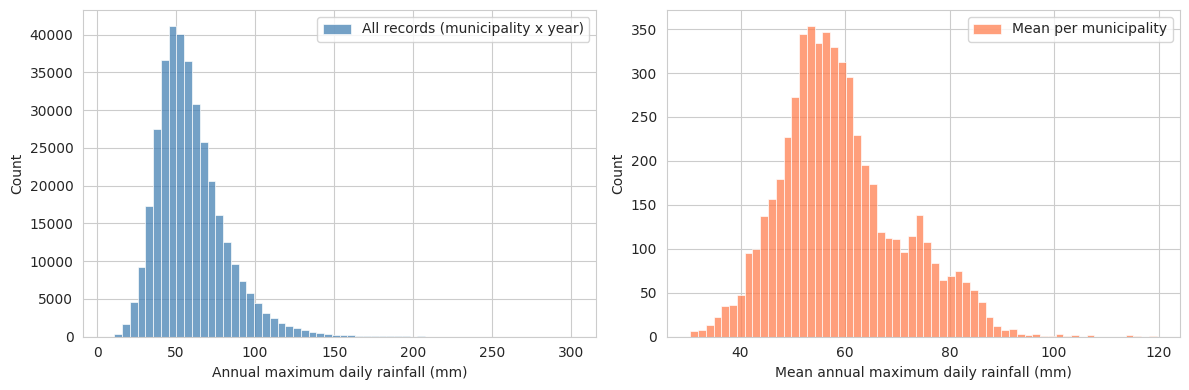

In [7]:
print('=== Annual maximum daily rainfall (mm/day) — all records (municipality x year) ===')
display(df_long['chuva_max_diaria_mm'].describe().round(2))

print()
print('=== Mean annual maximum daily rainfall per municipality (65 years each) ===')
display(df['chuva_media'].describe().round(2))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_long['chuva_max_diaria_mm'].dropna(), bins=60, ax=axs[0], color='steelblue',
             label='All records (municipality x year)')
axs[0].set_xlabel('Annual maximum daily rainfall (mm)')
axs[0].legend()

sns.histplot(df['chuva_media'], bins=60, ax=axs[1], color='coral',
             label='Mean per municipality')
axs[1].set_xlabel('Mean annual maximum daily rainfall (mm)')
axs[1].legend()

plt.tight_layout()
plt.savefig('annual_max_daily_rainfall_histograms.png', dpi=600, bbox_inches='tight')
plt.show()

## 3. Descriptive statistics by state

Municipalities ordered from the state with the highest to the lowest average annual maximum daily rainfall.

In [8]:
tabela_uf = df.groupby('uf').agg(
    n_municipios=('codigo_ibge', 'count'),
    chuva_media=('chuva_media', 'mean'),
    chuva_desvio=('chuva_media', 'std'),
    cv_medio=('cv', 'mean'),
    idf_r2_medio=('idf_r2', 'mean'),
).round(3).sort_values('chuva_media', ascending=False)
ordem_uf = tabela_uf.index.tolist()
tabela_uf


,n_municipios,chuva_media,chuva_desvio,cv_medio,idf_r2_medio
uf,,,,,
RS,497,77.170,6.169,0.291,0.999
PR,399,73.386,8.864,0.299,0.999
SC,295,73.035,5.907,0.295,0.999
RJ,92,62.932,9.818,0.341,0.999
SP,645,62.136,8.215,0.295,0.999
ES,77,62.132,5.488,0.310,0.999
AC,22,61.987,7.378,0.438,0.999
PA,144,58.568,7.002,0.257,0.999
RO,52,58.025,5.696,0.273,0.999


/tmp/ipykernel_4518/926309310.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='uf', y='chuva_media', order=ordem_uf, palette='Blues_r', ax=ax)
/tmp/ipykernel_4518/926309310.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


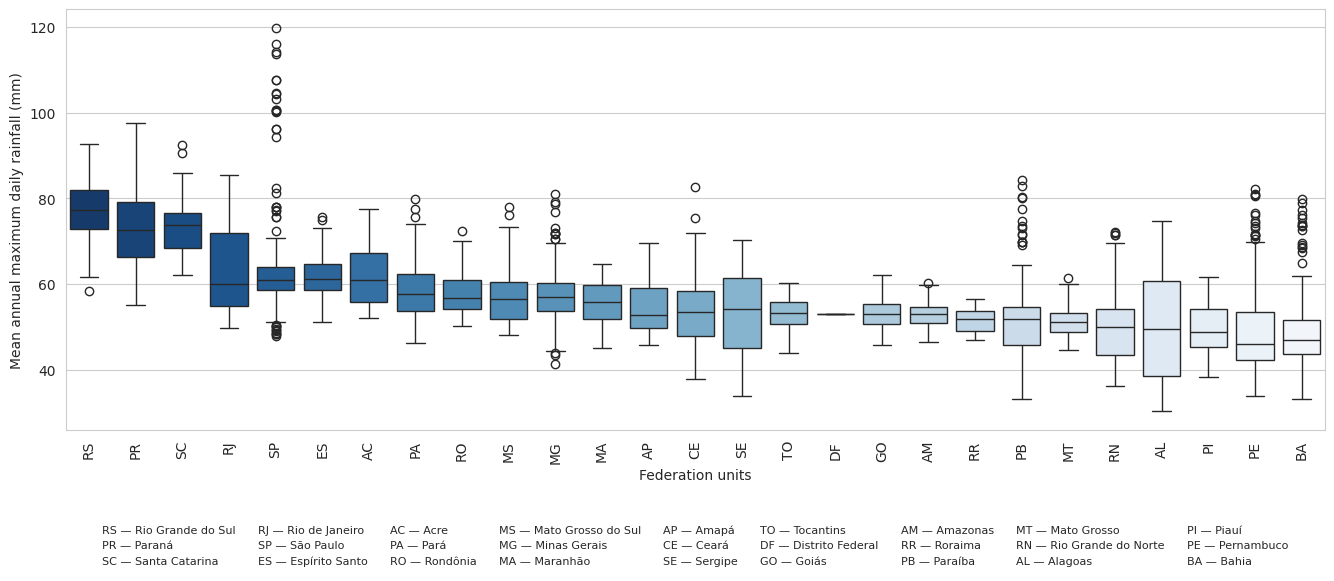

In [24]:
uf_nomes = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas',
    'BA': 'Bahia', 'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo',
    'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso', 'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná',
    'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x='uf', y='chuva_media', order=ordem_uf, palette='Blues_r', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_ylabel('Mean annual maximum daily rainfall (mm)')
ax.set_xlabel('Federation units')
#ax.set_title('Distribution of mean annual maximum daily rainfall by Federation Unit')

legend_handles = [
    plt.Line2D([], [], linestyle='none', marker='', label=f'{uf} — {uf_nomes[uf]}')
    for uf in ordem_uf
]
ax.legend(handles=legend_handles, ncol=9, loc='upper center', bbox_to_anchor=(0.5, -0.2),
          frameon=False, handlelength=0, handletextpad=0, fontsize=8)

plt.tight_layout()
plt.savefig('rainfall_boxplot_by_uf.png', dpi=600, bbox_inches='tight')
plt.show()

## 4. Winning statistical distribution (Gumbel/GEV/Normal/Log-Normal/Weibull/Gamma)

Which distribution was chosen (lowest KS statistic among those accepted) for each municipality's annual maxima series, and how this varies by state.

Frequência nacional das distribuições escolhidas:


,count
distribuicao,
GEV,1489
Weibull,1201
Gumbel,1139
Log-Normal,845
Gama,721
Normal,174


,proportion
distribuicao,
GEV,26.7%
Weibull,21.6%
Gumbel,20.5%
Log-Normal,15.2%
Gama,12.9%
Normal,3.1%


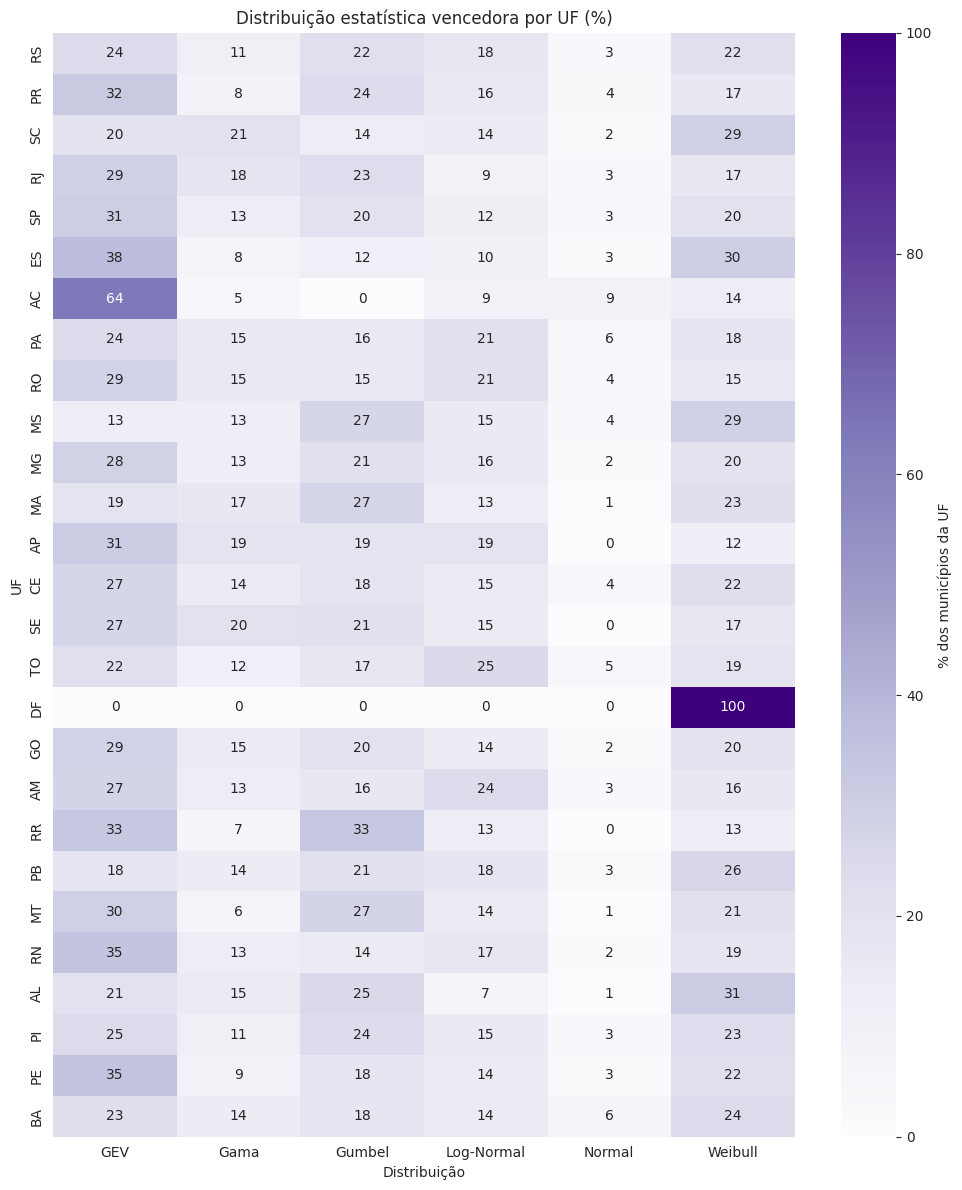

In [19]:
print('Frequência nacional das distribuições escolhidas:')
display(df['distribuicao'].value_counts())
print()
display((100 * df['distribuicao'].value_counts(normalize=True)).round(1).astype(str) + '%')

tabela_dist_pct = pd.crosstab(df['uf'], df['distribuicao'], normalize='index') * 100

plt.figure(figsize=(10, 12))
sns.heatmap(tabela_dist_pct.loc[ordem_uf], annot=True, fmt='.0f', cmap='Purples', cbar_kws={'label': '% dos municípios da UF'})
plt.title('Distribuição estatística vencedora por UF (%)')
plt.xlabel('Distribuição')
plt.ylabel('UF')
plt.tight_layout()
plt.show()


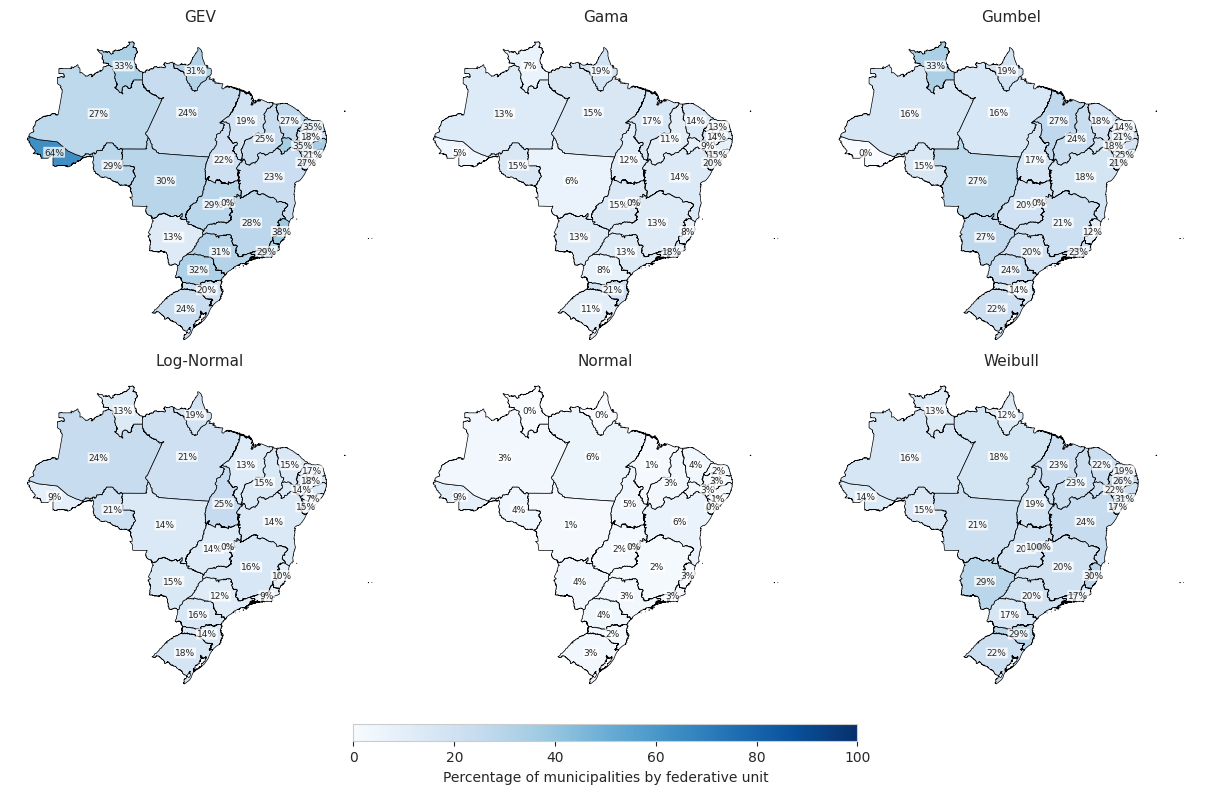

In [25]:
import numpy as np
import geobr

# Carrega o shapefile dos estados brasileiros (uma vez, fora do loop)
gdf_uf = geobr.read_state(year=2020)
gdf_uf = gdf_uf.merge(tabela_dist_pct, left_on='abbrev_state', right_index=True, how='left')

distribuicoes = tabela_dist_pct.columns.tolist()
n = len(distribuicoes)
ncols = 3
nrows = int(np.ceil(n / ncols))

vmin, vmax = tabela_dist_pct.values.min(), tabela_dist_pct.values.max()

fig, axs = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows))
axs = axs.flatten()

for i, dist in enumerate(distribuicoes):
    ax = axs[i]
    gdf_uf.plot(column=dist, cmap='Blues', linewidth=0.5, edgecolor='black',
                ax=ax, vmin=vmin, vmax=vmax, legend=False)
    for _, row in gdf_uf.iterrows():
        valor = row[dist]
        if pd.notna(valor):
            ax.annotate(f'{valor:.0f}%', xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                        ha='center', va='center', fontsize=6.5,
                        bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                                  edgecolor='none', alpha=0.75))
    ax.set_title(dist, fontsize=11, pad=4)
    ax.axis('off')
    ax.set_aspect('equal')

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.10, wspace=0.02, hspace=0.05)

sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Percentage of municipalities by federative unit')

#fig.suptitle('Distribuição estatística vencedora por UF (%)', y=0.96)
plt.savefig('distribuicoes_mapas_brasil.png', dpi=600, bbox_inches='tight')
plt.show()

## 5. IDF equation coefficients by state

Equation: `I(T, t) = k · Tᵃ / (t + b)ᶜ` — see `calcular_idf_municipios.py` for the calibration method (log-linear regression with a sweep over `b`).

⚠️ **Note**: as documented in `MEMORIA_PROJETO.md`, `b` and `c` are practically constant across all of Brazil (an effect of the fixed DAEE/CETESB disaggregation factors applied nationwide) — the table below confirms this numerically (standard deviation of `b` and `c` is negligible relative to the mean). Only `k` and `a` carry a real difference between municipalities/states.

In [26]:
tabela_idf_uf = df.groupby('uf')[['idf_k', 'idf_a', 'idf_b', 'idf_c', 'idf_r2']].agg(['mean', 'std']).round(4)
display(tabela_idf_uf)

print(f"Nacional — b: média {df['idf_b'].mean():.3f}, desvio-padrão {df['idf_b'].std():.5f}")
print(f"Nacional — c: média {df['idf_c'].mean():.4f}, desvio-padrão {df['idf_c'].std():.6f}")
print(f"Nacional — k: média {df['idf_k'].mean():.1f}, desvio-padrão {df['idf_k'].std():.1f}")
print(f"Nacional — a: média {df['idf_a'].mean():.4f}, desvio-padrão {df['idf_a'].std():.4f}")


idf_k             idf_a            idf_b       idf_c       idf_r2  \
        mean       std    mean     std     mean  std   mean  std    mean   
uf                                                                         
AC  545.9467  106.1544  0.3174  0.1538  11.8272  0.0  0.758  0.0  0.9992   
AL  593.0668  152.6642  0.1678  0.0295  11.8272  0.0  0.758  0.0  0.9987   
AM  618.4374   48.7725  0.1316  0.0415  11.8272  0.0  0.758  0.0  0.9992   
AP  634.9604   85.6521  0.1360  0.0330  11.8272  0.0  0.758  0.0  0.9992   
BA  579.2043   97.5795  0.1579  0.0336  11.8272  0.0  0.758  0.0  0.9988   
CE  634.8570   96.3315  0.1614  0.0330  11.8272  0.0  0.758  0.0  0.9989   
DF  634.2837       NaN  0.1345     NaN  11.8272  NaN  0.758  NaN  0.9989   
ES  733.5604   67.1892  0.1505  0.0263  11.8272  0.0  0.758  0.0  0.9990   
GO  616.4669   50.5184  0.1454  0.0289  11.8272  0.0  0.758  0.0  0.9991   
MA  652.6744   58.4161  0.1360  0.0242  11.8272  0.0  0.758  0.0  0.9991   
MG  670.3823   65.6364  0.1446  0.0281  11.8272  0.0  0.758  0.0  0.9991   
MS  679.2786   87.1432  0.1318  0.0293  11.8272  0.0  0.758  0.0  0.9991   
MT  590.2709   47.9378  0.1389  0.0319  11.8272  0.0  0.758  0.0  0.9992   
PA  689.9153   94.6703  0.1308  0.0264  11.8272  0.0  0.758  0.0  0.9991   
PB  606.0148  104.8569  0.1686  0.0341  11.8272  0.0  0.758  0.0  0.9988   
PE  573.4381  134.1100  0.1836  0.0466  11.8272  0.0  0.758  0.0  0.9988   
PI  586.1079   74.7121  0.1487  0.0337  11.8272  0.0  0.758  0.0  0.9990   
PR  856.0608  114.3192  0.1499  0.0307  11.8272  0.0  0.758  0.0  0.9991   
RJ  717.4096  122.4536  0.1722  0.0502  11.8272  0.0  0.758  0.0  0.9990   
RN  581.2766  100.3992  0.1808  0.0476  11.8272  0.0  0.758  0.0  0.9989   
RO  656.4958   58.4477  0.1510  0.0719  11.8272  0.0  0.758  0.0  0.9992   
RR  594.8190   40.6693  0.1344  0.0270  11.8272  0.0  0.758  0.0  0.9992   
RS  911.3134   88.0293  0.1418  0.0275  11.8272  0.0  0.758  0.0  0.9991   
SC  857.7662   84.5485  0.1488  0.0311  11.8272  0.0  0.758  0.0  0.9990   
SE  625.4280  109.3508  0.1748  0.0203  11.8272  0.0  0.758  0.0  0.9988   
SP  720.9191  107.0343  0.1519  0.0334  11.8272  0.0  0.758  0.0  0.9991   
TO  629.5392   52.1326  0.1276  0.0304  11.8272  0.0  0.758  0.0  0.9991   

            
       std  
uf          
AC  0.0003  
AL  0.0002  
AM  0.0001  
AP  0.0002  
BA  0.0002  
CE  0.0002  
DF     NaN  
ES  0.0002  
GO  0.0002  
MA  0.0002  
MG  0.0001  
MS  0.0001  
MT  0.0001  
PA  0.0001  
PB  0.0003  
PE  0.0003  
PI  0.0002  
PR  0.0002  
RJ  0.0003  
RN  0.0002  
RO  0.0003  
RR  0.0001  
RS  0.0001  
SC  0.0002  
SE  0.0002  
SP  0.0002  
TO  0.0001

Nacional — b: média 11.827, desvio-padrão 0.00000
Nacional — c: média 0.7580, desvio-padrão 0.000000
Nacional — k: média 693.7, desvio-padrão 141.1
Nacional — a: média 0.1513, desvio-padrão 0.0378


In [29]:
df.columns

Index(['codigo_ibge', 'nome_municipio', 'uf', 'chuva_media', 'chuva_desvio',
       'chuva_mediana', 'chuva_min', 'chuva_max', 'n_anos_validos', 'cv',
       'distribuicao', 'ks_d', 'ks_p_valor', 'idf_k', 'idf_a', 'idf_b',
       'idf_c', 'idf_r2', 'idf_mae', 'idf_rmse', 'i_5min_5anos',
       'i_5min_10anos', 'i_5min_25anos', 'i_5min_50anos', 'i_5min_100anos',
       'i_10min_5anos', 'i_10min_10anos', 'i_10min_25anos', 'i_10min_50anos',
       'i_10min_100anos', 'i_15min_5anos', 'i_15min_10anos', 'i_15min_25anos',
       'i_15min_50anos', 'i_15min_100anos', 'i_20min_5anos', 'i_20min_10anos',
       'i_20min_25anos', 'i_20min_50anos', 'i_20min_100anos', 'i_25min_5anos',
       'i_25min_10anos', 'i_25min_25anos', 'i_25min_50anos', 'i_25min_100anos',
       'i_30min_5anos', 'i_30min_10anos', 'i_30min_25anos', 'i_30min_50anos',
       'i_30min_100anos', 'i_60min_5anos', 'i_60min_10anos', 'i_60min_25anos',
       'i_60min_50anos', 'i_60min_100anos', 'i_360min_5anos',
       'i_360min_10ano

/tmp/ipykernel_4518/1624085384.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='uf', y=coef, order=ordem_uf, ax=ax, palette=cor)
/tmp/ipykernel_4518/1624085384.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=13)
/tmp/ipykernel_4518/1624085384.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='uf', y=coef, order=ordem_uf, ax=ax, palette=cor)
/tmp/ipykernel_4518/1624085384.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.se

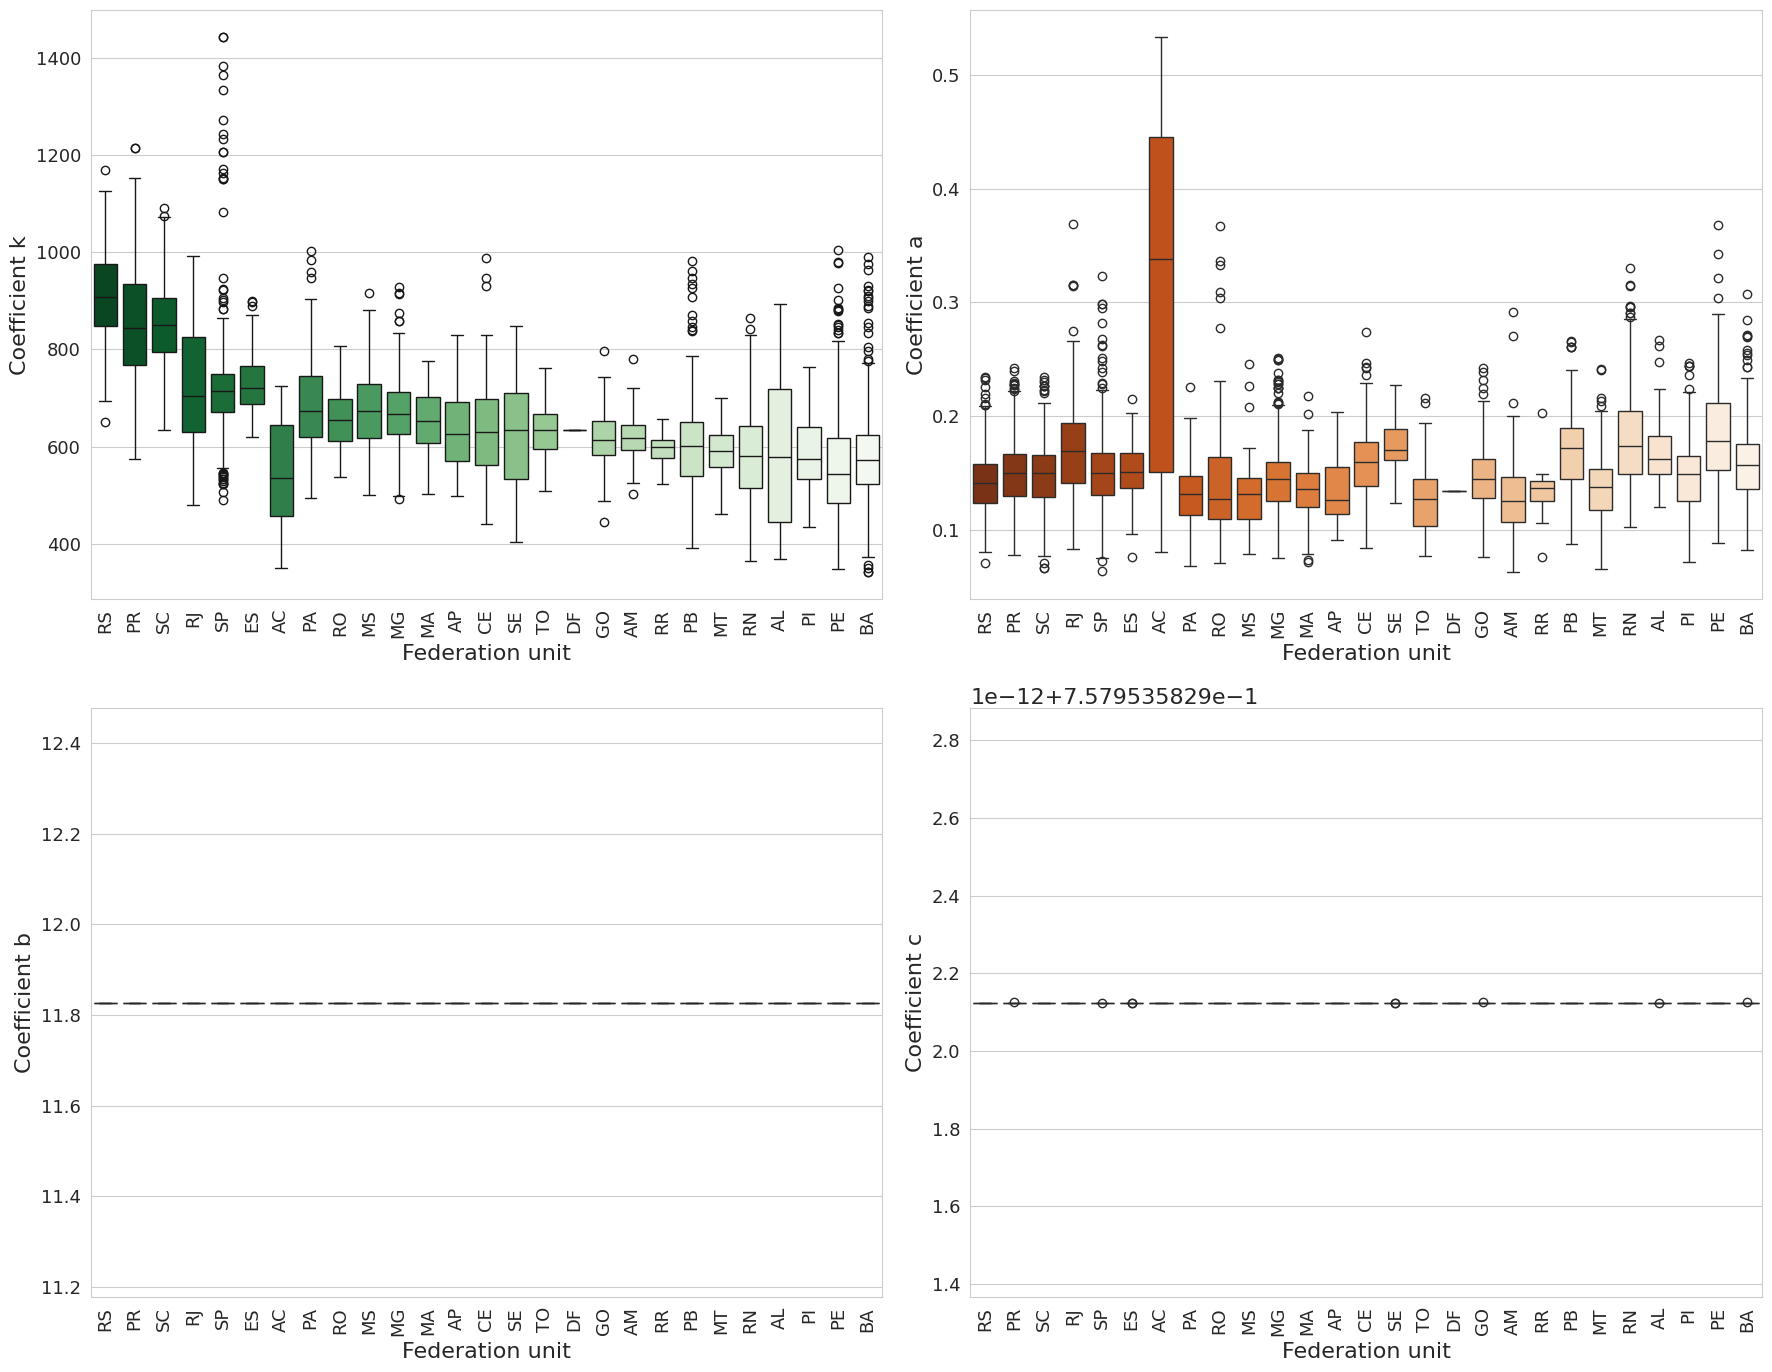

In [31]:
coeficientes = ['idf_k', 'idf_a', 'idf_b', 'idf_c']
titulos_en = ['Coefficient k', 'Coefficient a', 'Coefficient b', 'Coefficient c']
cores = ['Greens_r', 'Oranges_r', 'Blues_r', 'Purples_r']

plt.rcParams.update({'font.size': 16})

fig, axs = plt.subplots(2, 2, figsize=(18, 14))
axs = axs.flatten()

for ax, coef, titulo, cor in zip(axs, coeficientes, titulos_en, cores):
    sns.boxplot(data=df, x='uf', y=coef, order=ordem_uf, ax=ax, palette=cor)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=13)
    ax.set_xlabel('Federation unit', fontsize=16)
    ax.set_ylabel(titulo, fontsize=16)
    ax.tick_params(axis='y', labelsize=13)

plt.tight_layout()
plt.savefig('idf_coefficients_by_uf.png', dpi=600, bbox_inches='tight')
plt.show()


## 6. Choropleth maps (geobr)


### 6.1 Predominant statistical distribution by state

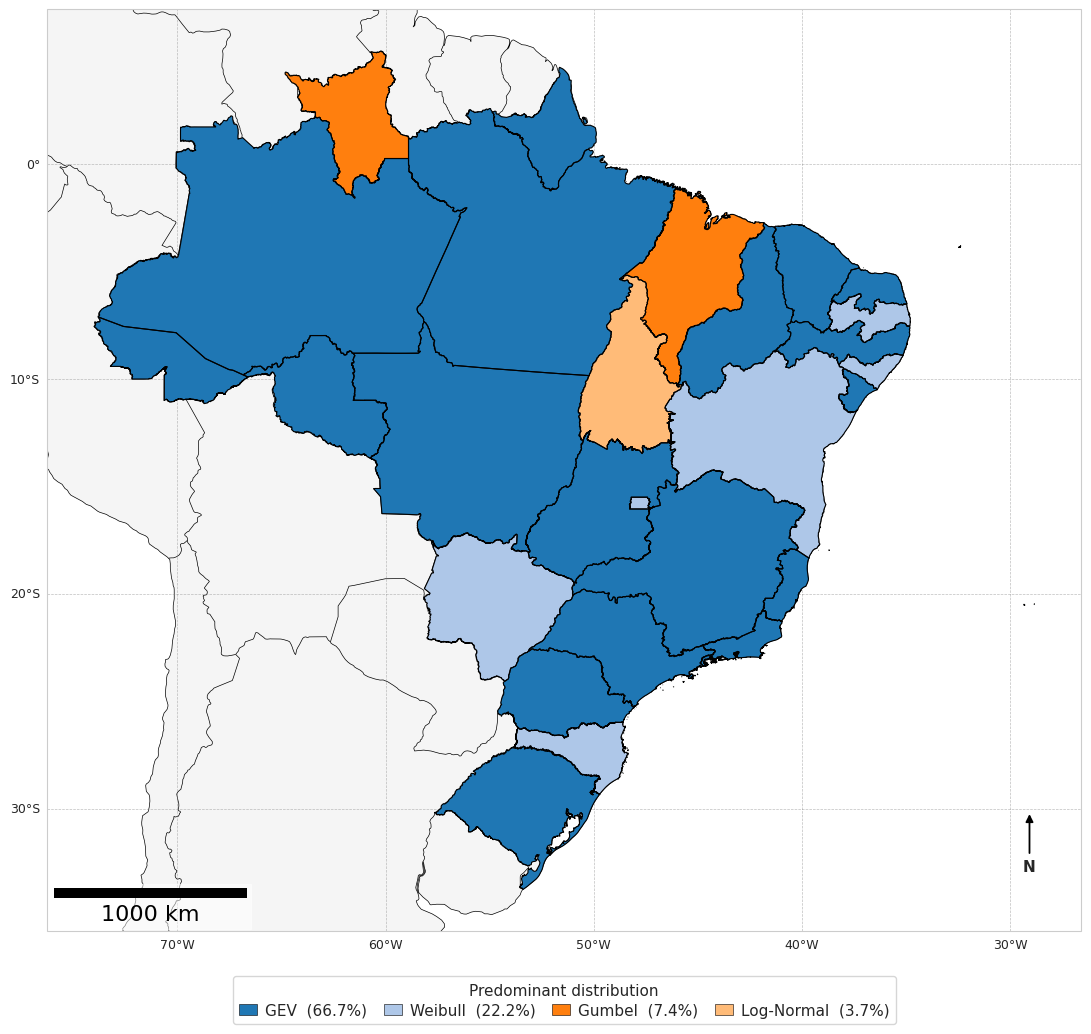

In [53]:

import warnings
warnings.filterwarnings('ignore')

def _base_map(ax, titulo):
    minx, miny, maxx, maxy = municipios_gdf.total_bounds
    dx = (maxx - minx) * 0.05; dy = (maxy - miny) * 0.05
    ax.set_extent([minx - dx, maxx + dx, miny - dy, maxy + dy], crs=ccrs.PlateCarree())
    ax.set_anchor('S')
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    return minx, miny, maxx, maxy


def _decoracoes(ax, minx, miny, maxx, maxy):
    estados_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8,
                               transform=ccrs.PlateCarree(), zorder=5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 9}; gl.ylabel_style = {'size': 9}
    ax.annotate('N', xy=(0.95, 0.13), xytext=(0.95, 0.07), xycoords='axes fraction',
                textcoords='axes fraction', ha='center', va='center', fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='-|>', linewidth=1.3, color='black'))
    lat_media = (miny + maxy) / 2
    dx_m = 111320 * np.cos(np.deg2rad(lat_media))
    largura_km = (maxx - minx) * dx_m / 1000
    escolhas_km = [10, 20, 25, 50, 100, 150, 200, 250, 500, 750, 1000]
    fixo_km = min(escolhas_km, key=lambda x: abs(x - largura_km / 4))
    ax.add_artist(ScaleBar(dx=dx_m, units='m', fixed_value=fixo_km * 1000, location='lower left',
                            box_alpha=0.5, scale_formatter=lambda value, unit: f'{int(value/1000)} km'))


def _cores_texto(classes):
    """Paleta reprodutível (tab20 + tab20b + tab20c) para colunas categóricas textuais."""
    base = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
    return {cls: base[i % len(base)] for i, cls in enumerate(classes)}


def _plot_mapa_texto(ax, gdf_, coluna_texto, titulo, titulo_fontsize=14):
    """Desenha, no eixo `ax`, um mapa categórico textual e devolve os `patches` da legenda."""
    dados = gdf_.dropna(subset=[coluna_texto])
    classes = dados[coluna_texto].value_counts().index.tolist()
    cores = _cores_texto(classes)
    minx, miny, maxx, maxy = _base_map(ax, titulo)
    for cls in classes:
        dados[dados[coluna_texto] == cls].plot(ax=ax, color=cores[cls], edgecolor='none',
                                                transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)
    # título do eixo removido a pedido

    total = dados[coluna_texto].notna().sum()
    cont = dados[coluna_texto].value_counts()
    return [mpatches.Patch(facecolor=cores[cls], edgecolor='black', linewidth=0.4,
                            label=f'{cls}  ({100*cont.get(cls,0)/total:.1f}%)') for cls in classes]


def plot_categorico_texto(gdf_, coluna_texto, titulo, legenda_titulo, savepath=None, ncol=5):
    """Mapa de coluna categórica textual, com legenda abaixo do mapa dividida em colunas."""
    n_classes = gdf_[coluna_texto].dropna().nunique()
    n_linhas_legenda = math.ceil(n_classes / ncol)

    row_h, title_h, pad, gap = 0.020, 0.035, 0.015, 0.03
    legend_h = title_h + n_linhas_legenda * row_h + pad
    bottom = min(0.60, legend_h + gap)

    fig = plt.figure(figsize=(11, 12 + legend_h * 6))
    ax = plt.axes([0.03, bottom, 0.94, 0.96 - bottom], projection=ccrs.PlateCarree())
    patches = _plot_mapa_texto(ax, gdf_, coluna_texto, titulo)

    fig.legend(handles=patches, title=legenda_titulo, loc='upper center',
               bbox_to_anchor=(0.5, bottom - gap),
               ncol=4,
               frameon=True, fontsize=11, title_fontsize=11,
               handlelength=1.2, columnspacing=1.1, handletextpad=0.5,
               borderpad=0.4, labelspacing=0.35)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()


# --- uso ---
traducao_dist = {'Gama': 'Gamma', 'GEV': 'GEV', 'Gumbel': 'Gumbel',
                  'Log-Normal': 'Log-Normal', 'Normal': 'Normal', 'Weibull': 'Weibull'}

distribuicao_predominante = (
    df.groupby('uf')['distribuicao']
    .agg(lambda s: s.value_counts().idxmax())
    .reset_index(name='distribuicao_predominante')
)
estados_dist = geobr.read_state(year=2020).merge(distribuicao_predominante, left_on='abbrev_state', right_on='uf', how='left')
estados_dist['distribuicao_en'] = estados_dist['distribuicao_predominante'].map(traducao_dist)

municipios_gdf = estados_dist
estados_gdf = estados_dist

plot_categorico_texto(
    estados_dist,
    coluna_texto='distribuicao_en',
    titulo='Predominant statistical distribution by Federation Unit',
    legenda_titulo='Predominant distribution',
    savepath='predominant_distribution_map.png',
    ncol=3
)

### 6.3 By municipality — average rainfall


2 municipality(ies) present in the geobr mesh but without rainfall data (shown in grey).
2 municipality(ies) present in the geobr mesh but without intensity data (shown in grey).
1 municipality(ies) with data but absent from the 2020 geobr mesh (not shown on the map, neither grey nor colored).


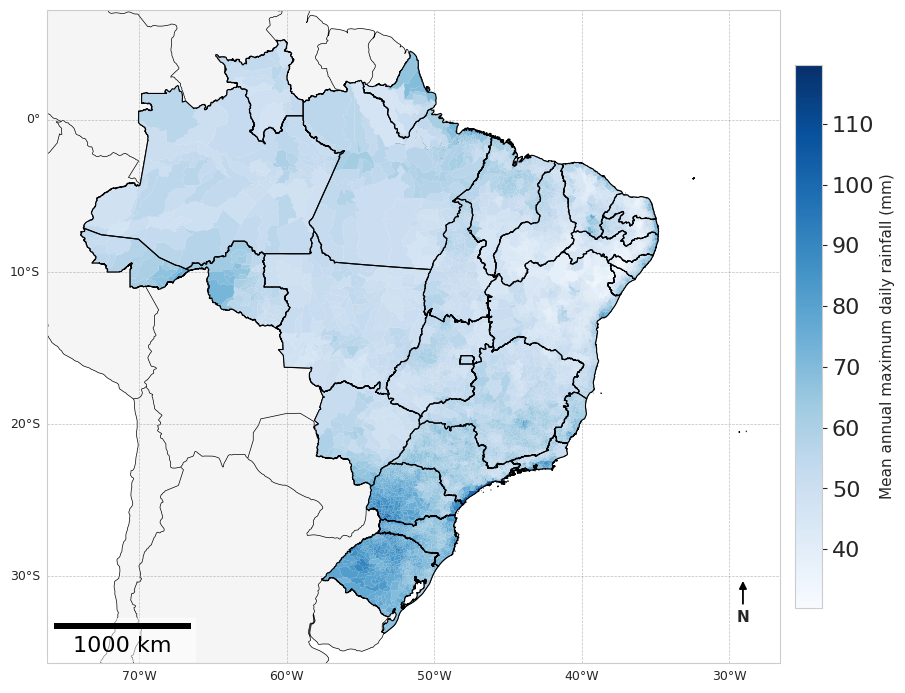

In [52]:
def _plot_mapa_continuo(ax, gdf_, coluna, cmap, cbar_label):
    """Desenha, no eixo `ax`, um mapa contínuo (coropletho numérico) e devolve o mappable
    para a colorbar."""
    minx, miny, maxx, maxy = _base_map(ax, None)
    plot = gdf_.plot(column=coluna, cmap=cmap, ax=ax, linewidth=0,
                      missing_kwds={'color': 'lightgrey', 'label': 'No data'},
                      transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)

    vmin, vmax = gdf_[coluna].min(), gdf_[coluna].max()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.035, pad=0.02)
    cbar.set_label(cbar_label, fontsize=11)
    return plot


# --- dados ---
mun_geo = geobr.read_municipality(code_muni='all', year=2020)
mun_geo['codigo_ibge'] = mun_geo['code_muni'].astype('int64').astype(str)
mun_geo = mun_geo.merge(df[['codigo_ibge', 'chuva_media', 'i_1440min_100anos']], on='codigo_ibge', how='left')

sem_dado_chuva = mun_geo['chuva_media'].isna().sum()
sem_dado_int = mun_geo['i_1440min_100anos'].isna().sum()
municipios_sem_poligono = set(df['codigo_ibge']) - set(mun_geo['codigo_ibge'])
print(f'{sem_dado_chuva} municipality(ies) present in the geobr mesh but without rainfall data (shown in grey).')
print(f'{sem_dado_int} municipality(ies) present in the geobr mesh but without intensity data (shown in grey).')
print(f'{len(municipios_sem_poligono)} municipality(ies) with data but absent from the 2020 geobr mesh '
      f'(not shown on the map, neither grey nor colored).')

municipios_gdf = mun_geo
estados_gdf = geobr.read_state(year=2020)

# --- mapa 1: chuva máxima diária anual média ---
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
_plot_mapa_continuo(ax, mun_geo, 'chuva_media', 'Blues',
                    'Mean annual maximum daily rainfall (mm)')
plt.savefig('mean_annual_max_daily_rainfall_map.png', dpi=600, bbox_inches='tight')
plt.show()


## 7. Numerical summary for the paper

In [49]:
print('=== Resumo para o artigo ===')
print(f'Total de municípios com curva IDF: {len(df)} de {len(df) + len(df_ignorados)} municípios brasileiros')
print(f'Período de análise: {df_long["ano"].min()}–{df_long["ano"].max()} ({df_long["ano"].nunique()} anos)')
print(f'Chuva máxima diária anual média nacional: {df["chuva_media"].mean():.1f} mm (desvio-padrão entre municípios: {df["chuva_media"].std():.1f} mm)')

uf_maior, uf_menor = tabela_uf.index[0], tabela_uf.index[-1]
print(f'UF com maior chuva máxima média: {uf_maior} ({tabela_uf.loc[uf_maior, "chuva_media"]:.1f} mm)')
print(f'UF com menor chuva máxima média: {uf_menor} ({tabela_uf.loc[uf_menor, "chuva_media"]:.1f} mm)')

dist_top = df['distribuicao'].value_counts()
print(f'Distribuição mais frequente nacionalmente: {dist_top.index[0]} '
      f'({dist_top.iloc[0]} municípios, {100 * dist_top.iloc[0] / len(df):.1f}%)')

print(f'R² da calibração IDF: média {df["idf_r2"].mean():.4f} (mín. {df["idf_r2"].min():.4f}, máx. {df["idf_r2"].max():.4f})')
print(f'Coeficiente b da equação IDF: {df["idf_b"].mean():.2f} ± {df["idf_b"].std():.5f} min '
      f'(praticamente constante nacionalmente — ver limitação metodológica)')
print(f'Coeficiente c da equação IDF: {df["idf_c"].mean():.4f} ± {df["idf_c"].std():.6f} '
      f'(praticamente constante nacionalmente — ver limitação metodológica)')


=== Resumo para o artigo ===
Total de municípios com curva IDF: 5569 de 5571 municípios brasileiros
Período de análise: 1961–2025 (65 anos)
Chuva máxima diária anual média nacional: 59.2 mm (desvio-padrão entre municípios: 11.6 mm)
UF com maior chuva máxima média: RS (77.2 mm)
UF com menor chuva máxima média: BA (48.2 mm)
Distribuição mais frequente nacionalmente: GEV (1489 municípios, 26.7%)
R² da calibração IDF: média 0.9990 (mín. 0.9978, máx. 0.9996)
Coeficiente b da equação IDF: 11.83 ± 0.00000 min (praticamente constante nacionalmente — ver limitação metodológica)
Coeficiente c da equação IDF: 0.7580 ± 0.000000 (praticamente constante nacionalmente — ver limitação metodológica)


## 8. Methodological notes

(Full detail in `MEMORIA_PROJETO.md`.)

1. **Sampling at the centroid, not the municipal polygon**: each value represents the 0.1° (~11 km) pixel of the Xavier BR-DWGD grid that contains the municipality's centroid, not the spatial maximum within the municipal territory.
2. **KS test with parameters estimated from the sample itself** tends to accept distributions "too easily" (a known issue — the Lilliefors correction was not applied).
3. **Distributions with no extreme-value-theory justification** (Normal, Gamma, Weibull) were tested alongside Gumbel/GEV — they can win the fit to the "body" of the distribution without necessarily describing the tail well.
4. **DAEE/CETESB (1980) disaggregation factors are regional (SP)**, applied here to every municipality in Brazil — direct consequence: the `b` and `c` coefficients of the IDF equation come out practically constant nationwide (section 5), reflecting the fixed shape of the disaggregation, not a real difference in sub-daily rainfall regime between regions.
5. **R²/MAE/RMSE of the IDF calibration are optimistic**: the 60 points (12 durations × 5 return periods) used in the calibration are not independent observations — they are quantiles extrapolated from a smooth curve derived from only 65 annual values per municipality.
6. **Two municipalities without a valid series** (Fernando de Noronha — outside the grid coverage; Vitória/ES — asset centroid with an incorrect coordinate, falling in the ocean) were excluded from the whole analysis.
7. **Boa Esperança do Norte (MT)** is absent from the 2020 `geobr` geographic mesh used in the municipal maps (a consequence of the mesh being from 2020 and the municipality possibly being more recent) — present in every other statistic.
